In [2]:
import sys
import os

# !pip install pandas
# !pip install seaborn
# !pip install qiskit-aer
import pandas as pd
import numpy as np

import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skewnorm, t, chi2, gamma
from scipy.stats import kstest
import json
import math

from qiskit.synthesis import LieTrotter
from qiskit.transpiler import CouplingMap
from qiskit_addon_utils.problem_generators import generate_xyz_hamiltonian
from qiskit_addon_utils.problem_generators import generate_time_evolution_circuit
from qiskit.quantum_info import SparsePauliOp

src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'utils'))
if src_path not in sys.path:
    sys.path.append(src_path)

# from qiskit_addon_obp.classical_shadows import run_shadow, calculate_shadow_sample_complexity
# from qiskit_addon_obp.run import run_many, obp_protocol
# from qiskit_addon_obp.obp import run_backpropagation

86.33333333333333
0.044565194998175184
Intersection at num_total_shots ≈ 7266.84
OBP-Shadow improvement is 6.00 times the minimum number of measurements for the coefficient truncation method.


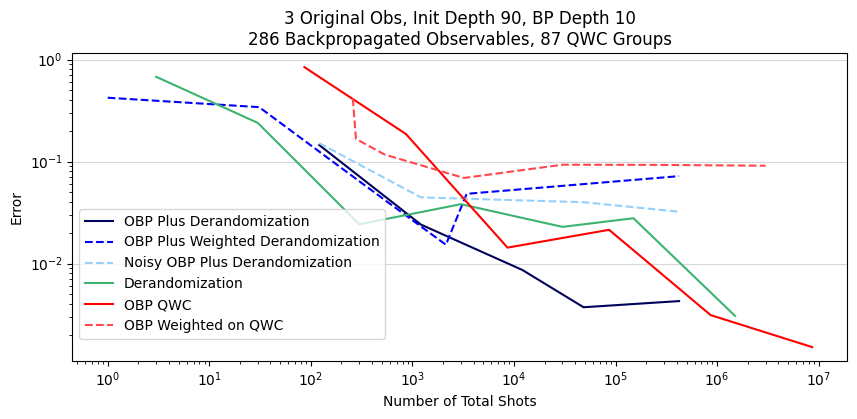

In [3]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data2'))
noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))
combined_weight_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'combined_weight_data'))
optimal_allocation_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_optimal_shot_allocation'))

coef_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs3.pkl')
noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs3.pkl')
coef_weight_df = pd.read_pickle(f'{combined_weight_data_path}/coef-trunc_init90_bp10_obs3.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs3.pkl')
optimal_shot_df = pd.read_pickle(f'{optimal_allocation_data_path}/coef-trunc_init90_bp10_obs3.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_res_3.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

# optimal_shot_df['num_total_shots'] = optimal_shot_df['number of groups'] * optimal_shot_df['obp_shots']

obs_num = 3
coef_df['obs_group'] = coef_df.index // obs_num
noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num
coef_weight_df['obs_group'] = coef_weight_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
optimal_shot_df['obs_group'] = optimal_shot_df.index // obs_num

gb1 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_weight = coef_weight_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()
gb_optimal = optimal_shot_df.groupby('obs_group').agg({'obp_shots': 'sum', 'abs_bp_error_shots': 'mean'}).reset_index()
gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))

sns.lineplot(x=gb1['num_meas'], y=gb1['abs_total_error'], label='OBP Plus Derandomization', color='xkcd:dark blue')
sns.lineplot(x=gb_weight['num_meas'], y=gb_weight['abs_total_error'], label='OBP Plus Weighted Derandomization', color='blue', linestyle='--')

sns.lineplot(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy OBP Plus Derandomization', color='xkcd:light blue', linestyle='--')

sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Derandomization', color='mediumseagreen')
# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')
sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP QWC', color='red')
sns.lineplot(data=gb_optimal, x='obp_shots', y='abs_bp_error_shots', label='OBP Weighted on QWC', color='xkcd:light red', linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables, {int(math.ceil(obp_df["num_qwc_bp_obs"].mean()))} QWC Groups')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

plt.grid(which='major', alpha=0.5)
plt.grid(axis='x')

print(obp_df['num_qwc_bp_obs'].mean())

# y_hline = gb1['abs_total_error'].min()
print(sorted(gb_noisy['abs_total_error'])[-2])
y_hline = sorted(gb_noisy['abs_total_error'])[-2]
# print(gb1[gb1['abs_total_error'] == y_hline])
y_min = gb_noisy[gb_noisy['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

82.0
Intersection at num_total_shots ≈ 744827.65
OBP-Shadow improvement is 8.37 times the minimum number of measurements for the coefficient truncation method.


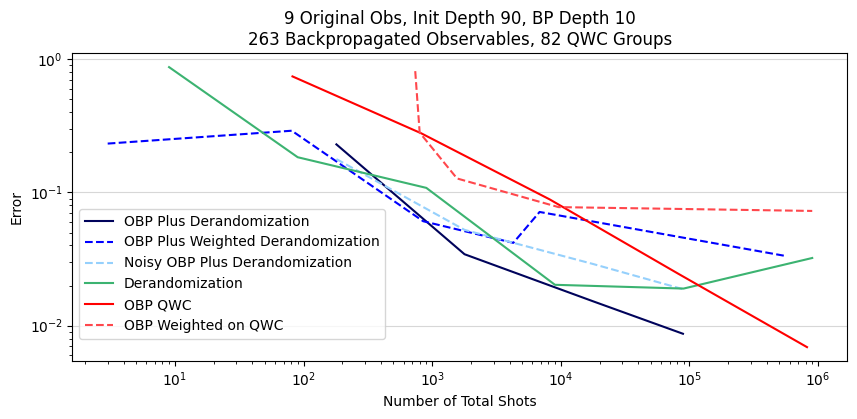

In [4]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data3'))
noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))
combined_weight_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'combined_weight_data'))
optimal_allocation_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_optimal_shot_allocation'))

coef_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs9.pkl')
noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs9.pkl')
coef_weight_df = pd.read_pickle(f'{combined_weight_data_path}/coef-trunc_init90_bp10_obs9.pkl')
optimal_shot_df = pd.read_pickle(f'{optimal_allocation_data_path}/coef-trunc_init90_bp10_obs9.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs9.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_res_9.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

# optimal_shot_df['num_total_shots'] = optimal_shot_df['number of groups'] * optimal_shot_df['obp_shots']

obs_num = 9
coef_df['obs_group'] = coef_df.index // obs_num
noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num
coef_weight_df['obs_group'] = coef_weight_df.index // obs_num
optimal_shot_df['obs_group'] = optimal_shot_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb1 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_weight = coef_weight_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_optimal = optimal_shot_df.groupby('obs_group').agg({'obp_shots': 'sum', 'abs_bp_error_shots': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))

sns.lineplot(x=gb1['num_meas'], y=gb1['abs_total_error'], label='OBP Plus Derandomization', color='xkcd:dark blue')
sns.lineplot(x=gb_weight['num_meas'], y=gb_weight['abs_total_error'], label='OBP Plus Weighted Derandomization', color='blue', linestyle='--')

sns.lineplot(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy OBP Plus Derandomization', color='xkcd:light blue', linestyle='--')

sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Derandomization', color='mediumseagreen')
# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')
sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP QWC', color='red')
sns.lineplot(data=gb_optimal, x='obp_shots', y='abs_bp_error_shots', label='OBP Weighted on QWC', color='xkcd:light red', linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables, {int(math.ceil(obp_df["num_qwc_bp_obs"].mean()))} QWC Groups')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

plt.grid(which='major', alpha=0.5)
plt.grid(axis='x')

print(obp_df['num_qwc_bp_obs'].mean())

y_hline = gb1['abs_total_error'].min()
y_min = gb1[gb1['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

154.0
Intersection at num_total_shots ≈ 1936144.08
OBP-Shadow improvement is 11.28 times the minimum number of measurements for the coefficient truncation method.


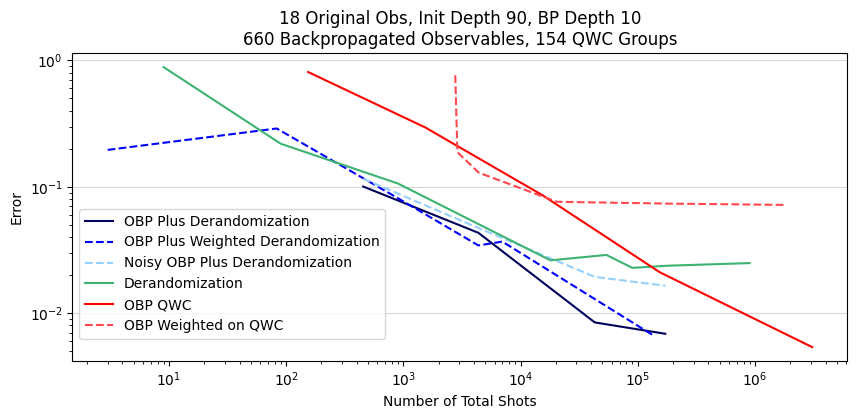

In [5]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data4'))
noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))
combined_weight_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'combined_weight_data'))
optimal_allocation_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_optimal_shot_allocation'))

coef_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs18.pkl')
noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs18.pkl')
coef_weight_df = pd.read_pickle(f'{combined_weight_data_path}/coef-trunc_init90_bp10_obs18.pkl')
optimal_shot_df = pd.read_pickle(f'{optimal_allocation_data_path}/coef-trunc_init90_bp10_obs18.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs18.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_res_18.pkl')

# obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
# obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['number of groups'] * obp_df['obp_shots']

optimal_shot_df['num_total_shots'] = optimal_shot_df['number of groups'] * optimal_shot_df['obp_shots']

obs_num = 18
coef_df['obs_group'] = coef_df.index // obs_num
noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num
coef_weight_df['obs_group'] = coef_weight_df.index // obs_num
optimal_shot_df['obs_group'] = optimal_shot_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb1 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_weight = coef_weight_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_optimal = optimal_shot_df.groupby('obs_group').agg({'obp_shots': 'sum', 'abs_bp_error_shots': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))

sns.lineplot(x=gb1['num_meas'], y=gb1['abs_total_error'], label='OBP Plus Derandomization', color='xkcd:dark blue')
sns.lineplot(x=gb_weight['num_meas'], y=gb_weight['abs_total_error'], label='OBP Plus Weighted Derandomization', color='blue', linestyle='--')

sns.lineplot(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy OBP Plus Derandomization', color='xkcd:light blue', linestyle='--')

sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Derandomization', color='mediumseagreen')
# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')
sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP QWC', color='red')
sns.lineplot(data=gb_optimal, x='obp_shots', y='abs_bp_error_shots', label='OBP Weighted on QWC', color='xkcd:light red', linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables, {int(math.ceil(obp_df["num_qwc_bp_obs"].mean()))} QWC Groups')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

plt.grid(which='major', alpha=0.5)
plt.grid(axis='x')

print(obp_df['num_qwc_bp_obs'].mean())

y_hline = gb1['abs_total_error'].min()
y_min = gb1[gb1['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

276.1111111111111
Intersection at num_total_shots ≈ 2819468.17
OBP-Shadow improvement is 28.79 times the minimum number of measurements for the coefficient truncation method.


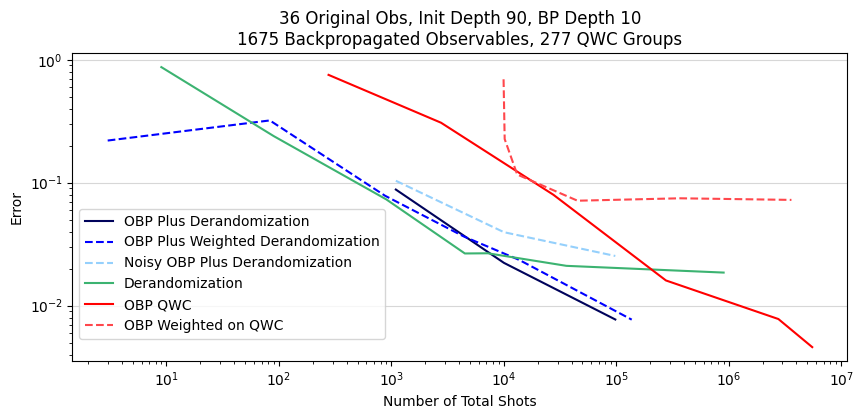

In [7]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data5'))
noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))
combined_weight_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'combined_weight_data'))
optimal_allocation_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_optimal_shot_allocation'))

coef_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs36.pkl')
noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs36.pkl')
coef_weight_df = pd.read_pickle(f'{combined_weight_data_path}/coef-trunc_init90_bp10_obs36.pkl')
optimal_shot_df = pd.read_pickle(f'{optimal_allocation_data_path}/coef-trunc_init90_bp10_obs36.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs36.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_res_36.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
# obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['number of groups'] * obp_df['obp_shots']

# optimal_shot_df['num_total_shots'] = optimal_shot_df['number of groups'] * optimal_shot_df['obp_shots']

obs_num = 36
coef_df['obs_group'] = coef_df.index // obs_num
noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num
coef_weight_df['obs_group'] = coef_weight_df.index // obs_num
optimal_shot_df['obs_group'] = optimal_shot_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb1 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_weight = coef_weight_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_optimal = optimal_shot_df.groupby('obs_group').agg({'obp_shots': 'sum', 'abs_bp_error_shots': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))

sns.lineplot(x=gb1['num_meas'], y=gb1['abs_total_error'], label='OBP Plus Derandomization', color='xkcd:dark blue')
sns.lineplot(x=gb_weight['num_meas'], y=gb_weight['abs_total_error'], label='OBP Plus Weighted Derandomization', color='blue', linestyle='--')

sns.lineplot(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy OBP Plus Derandomization', color='xkcd:light blue', linestyle='--')

sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Derandomization', color='mediumseagreen')
# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')
sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP QWC', color='red')
sns.lineplot(data=gb_optimal, x='obp_shots', y='abs_bp_error_shots', label='OBP Weighted on QWC', color='xkcd:light red', linestyle='--')

# plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')


plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables, {int(math.ceil(obp_df["number of groups"].mean()))} QWC Groups')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

plt.grid(which='major', alpha=0.5)
plt.grid(axis='x')

print(obp_df['number of groups'].mean())

y_hline = gb1['abs_total_error'].min()
y_min = gb1[gb1['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

In [4]:
obp_df

,backpropagated slices,number of terms,number of groups,max error,error is bounded by,bp_obs,bp_circuit,obs,circuit,bp_circuit_depth,...,obp_shots,circuit_depth,abs_bp_error_shots,bp_error_shots,abs_bp_error_state,bp_error_state,num_bp_obs,num_qwc_bp_obs,num_total_shots,obs_group
0,80,248,79,0.0001,0.007996,"[[[SparsePauliOp(['ZZIIIIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",ZZIIIIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,1,90,0.311190,0.311190,0.000004,-0.000004,248,79,79,0
1,80,316,90,0.0001,0.007997,"[[[SparsePauliOp(['ZXIIIIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",ZXIIIIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,1,90,0.961106,0.961106,0.000062,-0.000062,316,90,90,0
2,80,293,90,0.0001,0.008000,"[[[SparsePauliOp(['ZYIIIIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",ZYIIIIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,1,90,1.655052,1.655052,0.000038,0.000038,293,90,90,0
3,80,275,84,0.0001,0.007998,"[[[SparsePauliOp(['XXIIIIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",XXIIIIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,1,90,1.236718,-1.236718,0.000006,-0.000006,275,84,84,0
4,80,204,65,0.0001,0.007997,"[[[SparsePauliOp(['XZIIIIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",XZIIIIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,1,90,0.261183,0.261183,0.000153,-0.000153,204,65,65,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,80,3196,459,0.0001,0.007999,"[[[SparsePauliOp(['IIIXZIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",IIIXZIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,20000,90,0.003331,0.003331,0.000021,0.000021,3196,459,9180000,5
212,80,3742,514,0.0001,0.008000,"[[[SparsePauliOp(['IIIXYIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",IIIXYIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,20000,90,0.001238,0.001238,0.000027,-0.000027,3742,514,10280000,5
213,80,3530,484,0.0001,0.007996,"[[[SparsePauliOp(['IIIYYIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",IIIYYIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,20000,90,0.004675,-0.004675,0.000053,-0.000053,3530,484,9680000,5
214,80,2943,427,0.0001,0.007999,"[[[SparsePauliOp(['IIIYZIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",IIIYZIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,20000,90,0.010985,-0.010985,0.000055,0.000055,2943,427,8540000,5


In [ ]:
# plot the expectation value compared with theh weight (weight on x-axis, expectation value on y-axis)
# try to work out why the pauli weight might tend towards 0 when the ground state is not 0

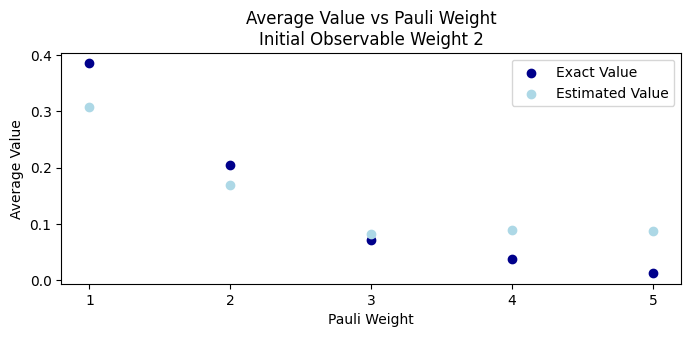

In [34]:
data_weight_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_weight'))
data_weight = pd.read_pickle(f'{data_weight_path}/coef-trunc_init90_bp30_obs1_weight2.pkl')

xyestimate = {}
xyexact = {}
xycount = {}

for d in data_weight['obs_shad_dict'][0]:

    if len([x for x in d['obs'] if x != 'I']) not in xyexact:
        xyexact[len([x for x in d['obs'] if x != 'I'])] = abs(d['exact'])
        xyestimate[len([x for x in d['obs'] if x != 'I'])] = abs(d['estimate'])
        xycount[len([x for x in d['obs'] if x != 'I'])] = 1
    else:
        xyexact[len([x for x in d['obs'] if x != 'I'])] += abs(d['exact'])
        xyestimate[len([x for x in d['obs'] if x != 'I'])] += abs(d['estimate'])
        xycount[len([x for x in d['obs'] if x != 'I'])] += 1

for k in xyexact:
    xyexact[k] = xyexact[k] / xycount[k]
    xyestimate[k] = xyestimate[k] / xycount[k]

plt.figure(figsize=(8, 3))

plt.scatter(xyexact.keys(), xyexact.values(), color='darkblue', label='Exact Value')
plt.scatter(xyestimate.keys(), xyestimate.values(), color='lightblue', label='Estimated Value')

plt.xticks([1, 2, 3, 4, 5])

plt.xlabel('Pauli Weight')
plt.ylabel('Average Value')
plt.title('Average Value vs Pauli Weight\nInitial Observable Weight 2')
plt.legend()

['ZZIIIIIIII', 'YYIIIIIIII', 'XXIIIIIIII', 'ZZXIIIIIII', 'ZZIXIIIIII', 'YYXIIIIIII', 'YYIXIIIIII', 'ZZZYIIIIII', 'ZZYZIIIIII', 'YYZYIIIIII', 'YYYZIIIIII', 'XXXIIIIIII', 'IIXIIIIIII', 'ZYIIIIIIII', 'YZIIIIIIII', 'ZYYYIIIIII', 'ZYZZIIIIII', 'XIIIIIIIII', 'IXIIIIIIII', 'ZYIXIIIIII', 'ZYXIIIIIII', 'ZYYZIIIIII', 'ZYZYIIIIII', 'YZYZIIIIII', 'YZZYIIIIII', 'XIYZIIIIII', 'XIZYIIIIII', 'IXYZIIIIII', 'IXZYIIIIII', 'YZXIIIIIII', 'XIXIIIIIII', 'IXXIIIIIII', 'IXIXIIIIII', 'ZZYIIIIIII', 'ZZZXIIIIII', 'YYYIIIIIII', 'XXYIIIIIII', 'XXZXIIIIII', 'ZZXZIIIIII', 'XXXZIIIIII', 'ZZZIIIIIII', 'YYZIIIIIII', 'YYYXIIIIII', 'XXZIIIIIII', 'XXYXIIIIII', 'XXXYIIIIII', 'ZYYIIIIIII', 'ZYZXIIIIII', 'YZYIIIIIII', 'XIYIIIIIII', 'IXYIIIIIII', 'ZYXZIIIIII', 'YZXZIIIIII', 'IXXZIIIIII', 'ZYYXIIIIII', 'ZYZIIIIIII', 'ZYXYIIIIII', 'YZZIIIIIII', 'XIXYIIIIII', 'IXXYIIIIII', 'XIZIIIIIII', 'IXZIIIIIII', 'YYXYIIIIII', 'ZXIIIIIIII', 'ZXXXIIIIII', 'YIIIIIIIII', 'XZIIIIIIII', 'IYIIIIIIII', 'IYXXIIIIII', 'ZXZZIIIIII', 'IYZZIIIIII', 'ZXXI

<BarContainer object of 5 artists>

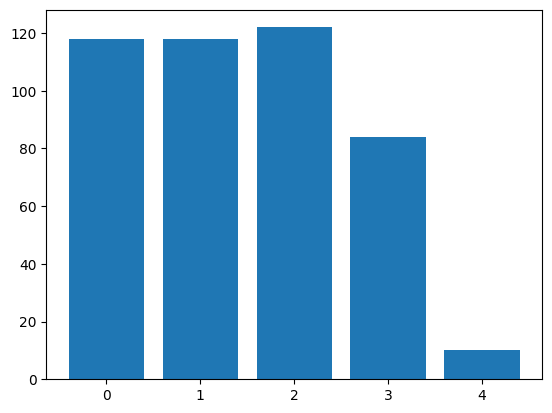

In [35]:
pauli_list = []

for p in data_weight['bp_obs'][0].paulis:
    pauli_list.append(p.to_label())

print(pauli_list)

position_dict = {}
for p in pauli_list:
    for s in range(len(p)):
        if p[s] != 'I':
            if s in position_dict:
                position_dict[s] += 1
            else:
                position_dict[s] = 1

print(data_weight['obs'][0])
plt.bar(position_dict.keys(), position_dict.values())

['ZZIIIIIIII', 'YYIIIIIIII', 'XXIIIIIIII', 'ZZXIIIIIII', 'ZZIXIIIIII', 'YYXIIIIIII', 'YYIXIIIIII', 'ZZZYIIIIII', 'ZZYZIIIIII', 'YYZYIIIIII', 'YYYZIIIIII', 'XXXIIIIIII', 'IIXIIIIIII', 'ZYIIIIIIII', 'YZIIIIIIII', 'ZYYYIIIIII', 'ZYZZIIIIII', 'XIIIIIIIII', 'IXIIIIIIII', 'ZYIXIIIIII', 'ZYXIIIIIII', 'ZYYZIIIIII', 'ZYZYIIIIII', 'YZYZIIIIII', 'YZZYIIIIII', 'XIYZIIIIII', 'XIZYIIIIII', 'IXYZIIIIII', 'IXZYIIIIII', 'YZXIIIIIII', 'XIXIIIIIII', 'IXXIIIIIII', 'IXIXIIIIII', 'ZZYIIIIIII', 'ZZZXIIIIII', 'YYYIIIIIII', 'XXYIIIIIII', 'XXZXIIIIII', 'ZZXZIIIIII', 'XXXZIIIIII', 'ZZZIIIIIII', 'YYZIIIIIII', 'YYYXIIIIII', 'XXZIIIIIII', 'XXYXIIIIII', 'XXXYIIIIII', 'ZYYIIIIIII', 'ZYZXIIIIII', 'YZYIIIIIII', 'XIYIIIIIII', 'IXYIIIIIII', 'ZYXZIIIIII', 'YZXZIIIIII', 'IXXZIIIIII', 'ZYYXIIIIII', 'ZYZIIIIIII', 'ZYXYIIIIII', 'YZZIIIIIII', 'XIXYIIIIII', 'IXXYIIIIII', 'XIZIIIIIII', 'IXZIIIIIII', 'YYXYIIIIII', 'ZXIIIIIIII', 'ZXXXIIIIII', 'YIIIIIIIII', 'XZIIIIIIII', 'IYIIIIIIII', 'IYXXIIIIII', 'ZXZZIIIIII', 'IYZZIIIIII', 'ZXXI

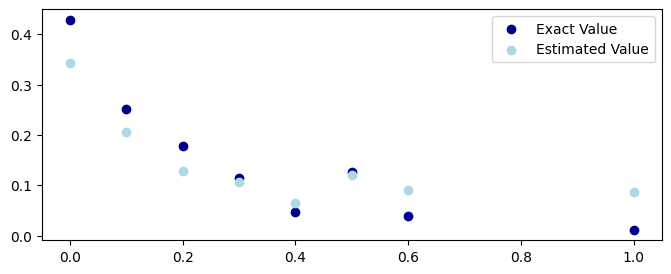

In [36]:
pauli_list = []

for p in data_weight['bp_obs'][0].paulis:
    pauli_list.append(p.to_label())

print(pauli_list)

position_dict = {}
for p in pauli_list:
    for s in range(len(p)):
        if p[s] != 'I':
            if s in position_dict:
                position_dict[s] += 1
            else:
                position_dict[s] = 1

xyestimate = {}
xyexact = {}
xycount = {}

for d in data_weight['obs_shad_dict'][0]:
    p = d['obs'] 
    pos = 0
    for s in range(len(p)):
        if p[s] != 'I':
            pos += s

    pos_avg = pos / 10
    if pos_avg not in xyexact:
        xyexact[pos_avg] = abs(d['exact'])
        xyestimate[pos_avg] = abs(d['estimate'])
        xycount[pos_avg] = 1
    else:
        xyexact[pos_avg] += abs(d['exact'])
        xyestimate[pos_avg] += abs(d['estimate'])
        xycount[pos_avg] += 1


# print(test['obs'][0])
# plt.bar(position_dict.keys(), position_dict.values())

for k in xyexact:
    xyexact[k] = xyexact[k] / xycount[k]
    xyestimate[k] = xyestimate[k] / xycount[k]

plt.figure(figsize=(8, 3))

plt.scatter(xyexact.keys(), xyexact.values(), color='darkblue', label='Exact Value')
plt.scatter(xyestimate.keys(), xyestimate.values(), color='lightblue', label='Estimated Value')

# plt.xticks(list(range(1,11)))

plt.legend()

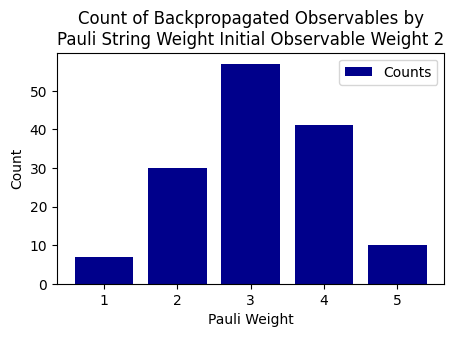

In [37]:
p = {}
for d in data_weight['obs_shad_dict'][0]:

    if len([x for x in d['obs'] if x != 'I']) not in p:
        p[len([x for x in d['obs'] if x != 'I'])] = 1
    else:
        p[len([x for x in d['obs'] if x != 'I'])] += 1

plt.figure(figsize=(5, 3))

plt.bar(p.keys(), p.values(), color='darkblue', label='Counts')

plt.xticks([1, 2, 3, 4, 5])

plt.xlabel('Pauli Weight')
plt.ylabel('Count')
plt.title('Count of Backpropagated Observables by\nPauli String Weight Initial Observable Weight 2')
plt.legend()

{2: np.complex128(1.1393525963904148+2.8231713756259034e-18j), 3: np.complex128(-0.03165709638978114+2.1245279549260933e-18j), 4: np.complex128(-0.011575155559541857+1.0056360248748202e-20j), 1: np.complex128(0.030723496905243713+8.335226899513356e-19j), 5: np.complex128(0.0001874245839340396+1.1383560806944145e-21j)}


/opt/anaconda3/envs/qiskit-obp/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/qiskit-obp/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


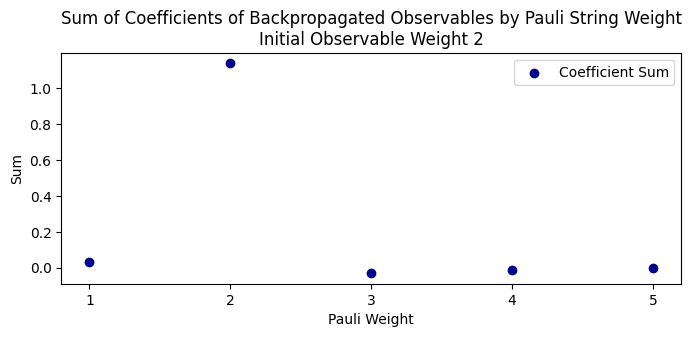

In [38]:
coef_dict = {}
for p, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    if len([x for x in str(p) if x != 'I']) not in coef_dict:
        coef_dict[len([x for x in str(p) if x != 'I'])] = c
    else:
        coef_dict[len([x for x in str(p) if x != 'I'])] += c

print(coef_dict)
plt.figure(figsize=(8, 3))

plt.scatter(coef_dict.keys(), coef_dict.values(), color='darkblue', label='Coefficient Sum')

plt.xticks([1, 2, 3, 4, 5])

plt.xlabel('Pauli Weight')
plt.ylabel('Sum')
plt.title('Sum of Coefficients of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 2')
plt.legend()

/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_91424/3499375961.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_est_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_91424/3499375961.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_exact_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_91424/3499375961.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_est_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_sh

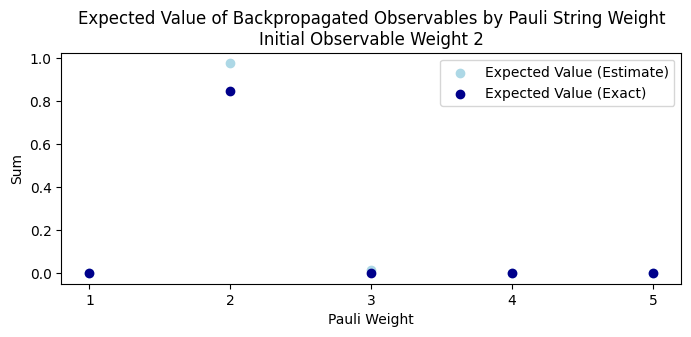

In [39]:
# estimated expected value by pauli weight
# exact expected value by pauli weight
# scatter plot
ev_est_dict = {}
ev_exact_dict = {}
obs_shad_df = pd.DataFrame(data_weight['obs_shad_dict'][0])
for p, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    if len([x for x in str(p) if x != 'I']) not in ev_est_dict:
        ev_est_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
        ev_exact_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])
    else:
        ev_est_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
        ev_exact_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])

# print(ev_est_dict)
plt.figure(figsize=(8, 3))

plt.scatter(ev_est_dict.keys(), ev_est_dict.values(), color='lightblue', label='Expected Value (Estimate)')
plt.scatter(ev_exact_dict.keys(), ev_exact_dict.values(), color='darkblue', label='Expected Value (Exact)')

plt.xticks([1, 2, 3, 4, 5])

plt.xlabel('Pauli Weight')
plt.ylabel('Sum')
plt.title('Expected Value of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 2')
plt.legend()

{2: np.complex128(1.1393525963904148+2.8231713756259034e-18j), 3: np.complex128(-0.03165709638978114+2.1245279549260933e-18j), 4: np.complex128(-0.011575155559541857+1.0056360248748202e-20j), 1: np.complex128(0.030723496905243713+8.335226899513356e-19j), 5: np.complex128(0.0001874245839340396+1.1383560806944145e-21j)}


/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_91424/1235380652.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  est = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p_)]['estimate'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_91424/1235380652.py:41: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exact = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p_)]['exact'])


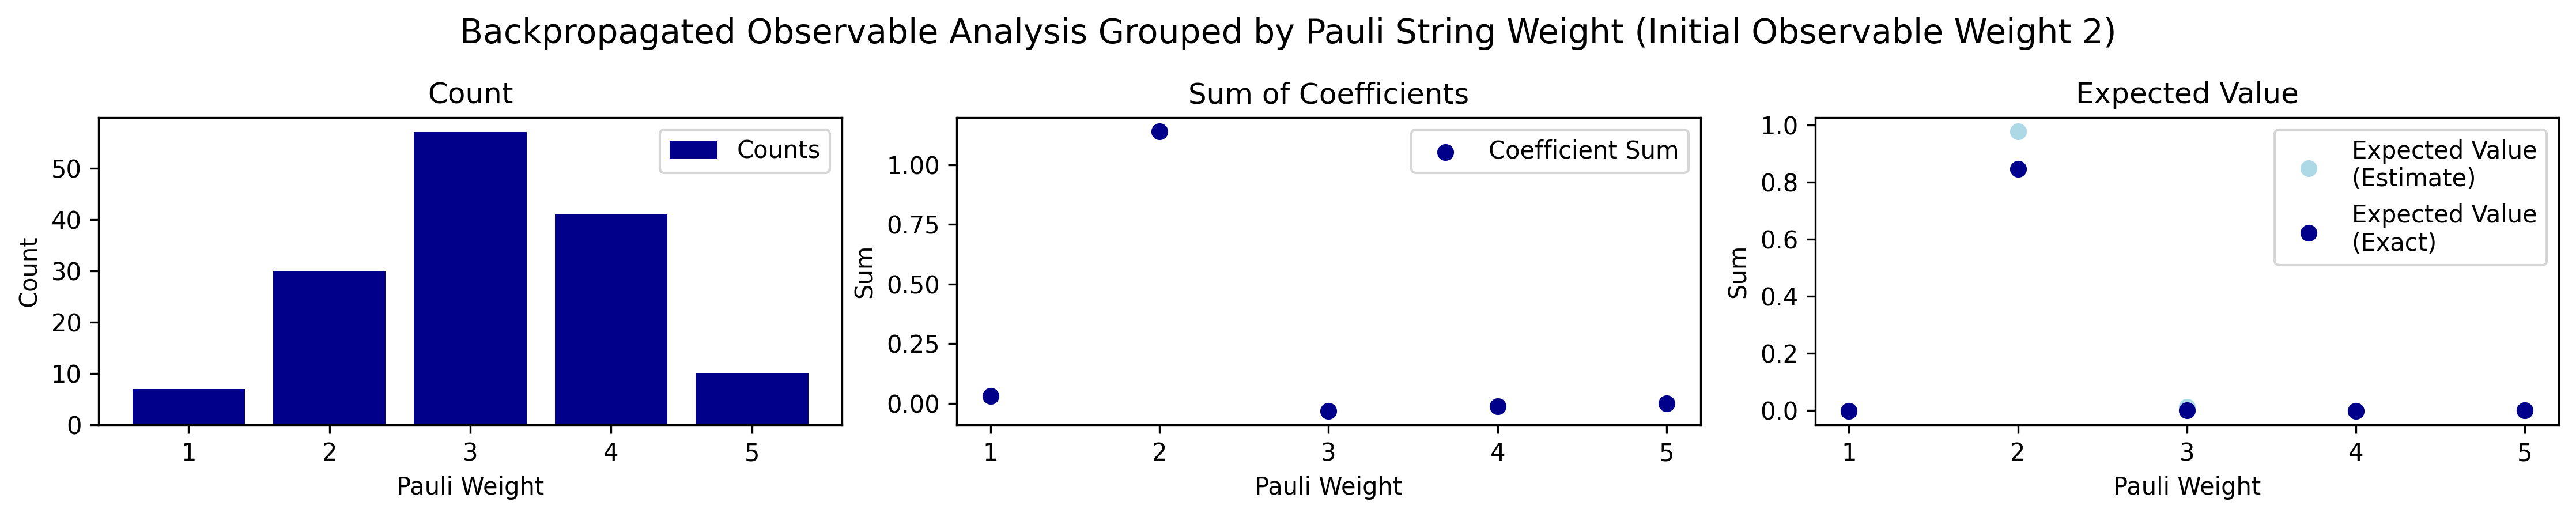

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3), dpi=300)
ax0, ax1, ax2 = axes

# --- Figure 1: Count of backpropagated observables by Pauli weight ---
p = {}
for d in data_weight['obs_shad_dict'][0]:
    w = len([x for x in d['obs'] if x != 'I'])
    p[w] = p.get(w, 0) + 1

ax0.bar(p.keys(), p.values(), color='darkblue', label='Counts')
ax0.set_xticks([1, 2, 3, 4, 5])
ax0.set_xlabel('Pauli Weight')
ax0.set_ylabel('Count')
ax0.set_title('Count')
ax0.legend()

# --- Figure 2: Sum of coefficients by Pauli weight ---
coef_dict = {}
for p_, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    w = len([x for x in str(p_) if x != 'I'])
    if w not in coef_dict:
        coef_dict[w] = c
    else:
        coef_dict[w] += c

print(coef_dict)
ax1.scatter(coef_dict.keys(), coef_dict.values(), color='darkblue', label='Coefficient Sum')
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_xlabel('Pauli Weight')
ax1.set_ylabel('Sum')
ax1.set_title('Sum of Coefficients')
ax1.legend()

# --- Figure 3: Expected value (estimate vs exact) by Pauli weight ---
ev_est_dict = {}
ev_exact_dict = {}
obs_shad_df = pd.DataFrame(data_weight['obs_shad_dict'][0])
for p_, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    w = len([x for x in str(p_) if x != 'I'])
    est = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p_)]['estimate'])
    exact = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p_)]['exact'])
    if w not in ev_est_dict:
        ev_est_dict[w] = est
        ev_exact_dict[w] = exact
    else:
        ev_est_dict[w] += est
        ev_exact_dict[w] += exact

ax2.scatter(ev_est_dict.keys(), ev_est_dict.values(), color='lightblue', label='Expected Value\n(Estimate)')
ax2.scatter(ev_exact_dict.keys(), ev_exact_dict.values(), color='darkblue', label='Expected Value\n(Exact)')
ax2.set_xticks([1, 2, 3, 4, 5])
ax2.set_xlabel('Pauli Weight')
ax2.set_ylabel('Sum')
ax2.set_title('Expected Value')
ax2.legend()


fig.suptitle('Backpropagated Observable Analysis Grouped by Pauli String Weight (Initial Observable Weight 2)', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 1.02])
# High-resolution export:
fig.savefig('pauli_weight_figures.png', dpi=300, bbox_inches='tight')

/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_91424/3250124871.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_est_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_91424/3250124871.py:44: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_exact_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_91424/3250124871.py:46: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_est_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_s

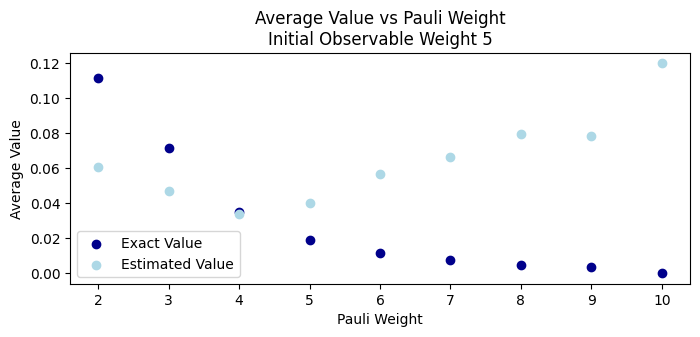

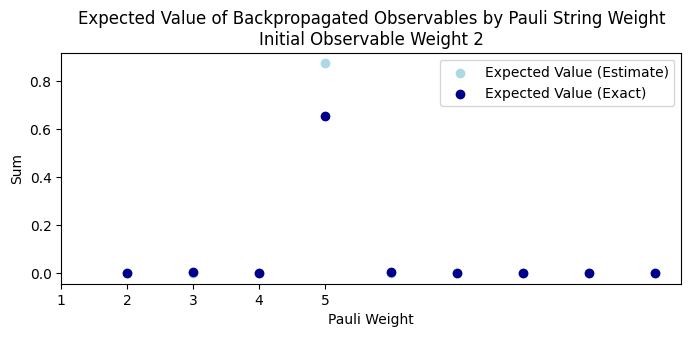

In [43]:
data_weight_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_weight'))
data_weight = pd.read_pickle(f'{data_weight_path}/coef-trunc_init90_bp30_obs1_weight5.pkl')

xyestimate = {}
xyexact = {}
xycount = {}

for d in data_weight['obs_shad_dict'][0]:

    if len([x for x in d['obs'] if x != 'I']) not in xyexact:
        xyexact[len([x for x in d['obs'] if x != 'I'])] = abs(d['exact'])
        xyestimate[len([x for x in d['obs'] if x != 'I'])] = abs(d['estimate'])
        xycount[len([x for x in d['obs'] if x != 'I'])] = 1
    else:
        xyexact[len([x for x in d['obs'] if x != 'I'])] += abs(d['exact'])
        xyestimate[len([x for x in d['obs'] if x != 'I'])] += abs(d['estimate'])
        xycount[len([x for x in d['obs'] if x != 'I'])] += 1

for k in xyexact:
    xyexact[k] = xyexact[k] / xycount[k]
    xyestimate[k] = xyestimate[k] / xycount[k]

plt.figure(figsize=(8, 3))

plt.scatter(xyexact.keys(), xyexact.values(), color='darkblue', label='Exact Value')
plt.scatter(xyestimate.keys(), xyestimate.values(), color='lightblue', label='Estimated Value')

# plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

plt.xlabel('Pauli Weight')
plt.ylabel('Average Value')
plt.title('Average Value vs Pauli Weight\nInitial Observable Weight 5')
plt.legend()

# estimated expected value by pauli weight
# exact expected value by pauli weight
# scatter plot
ev_est_dict = {}
ev_exact_dict = {}
obs_shad_df = pd.DataFrame(data_weight['obs_shad_dict'][0])
for p, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    if len([x for x in str(p) if x != 'I']) not in ev_est_dict:
        ev_est_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
        ev_exact_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])
    else:
        ev_est_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
        ev_exact_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])

# print(ev_est_dict)
plt.figure(figsize=(8, 3))

plt.scatter(ev_est_dict.keys(), ev_est_dict.values(), color='lightblue', label='Expected Value (Estimate)')
plt.scatter(ev_exact_dict.keys(), ev_exact_dict.values(), color='darkblue', label='Expected Value (Exact)')

plt.xticks([1, 2, 3, 4, 5])

plt.xlabel('Pauli Weight')
plt.ylabel('Sum')
plt.title('Expected Value of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 2')
plt.legend()

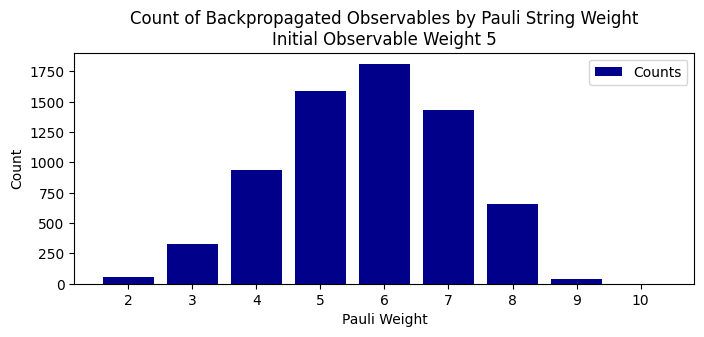

In [44]:
p = {}
for d in data_weight['obs_shad_dict'][0]:

    if len([x for x in d['obs'] if x != 'I']) not in p:
        p[len([x for x in d['obs'] if x != 'I'])] = 1
    else:
        p[len([x for x in d['obs'] if x != 'I'])] += 1

plt.figure(figsize=(8, 3))

plt.bar(p.keys(), p.values(), color='darkblue', label='Counts')

plt.xticks([2, 3, 4, 5, 6, 7, 8, 9, 10])

plt.xlabel('Pauli Weight')
plt.ylabel('Count')
plt.title('Count of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 5')
plt.legend()

{5: np.complex128(1.3676646802669399-1.6499166033741534e-18j), 6: np.complex128(-0.043692765503451726-5.08985435937726e-18j), 8: np.complex128(0.00025799160886913697-7.061384058191809e-21j), 3: np.complex128(0.000870079189753865+3.527361294252975e-18j), 4: np.complex128(0.13010102656863579-1.4421266620606477e-18j), 7: np.complex128(-0.014040079585263+2.806663941952231e-18j), 2: np.complex128(2.687289376194744e-05+1.0354988920817205e-19j), 9: np.complex128(3.882593025408344e-05+1.4917786291845668e-22j), 10: np.complex128(-2.308236766836145e-07+0j)}


/opt/anaconda3/envs/qiskit-obp/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/qiskit-obp/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


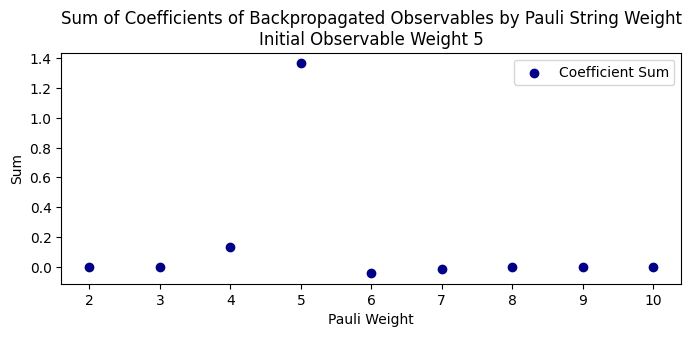

In [45]:
coef_dict = {}
for p, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    if len([x for x in str(p) if x != 'I']) not in coef_dict:
        coef_dict[len([x for x in str(p) if x != 'I'])] = c
    else:
        coef_dict[len([x for x in str(p) if x != 'I'])] += c

print(coef_dict)
plt.figure(figsize=(8, 3))

plt.scatter(coef_dict.keys(), coef_dict.values(), color='darkblue', label='Coefficient Sum')

# plt.xticks([1, 2, 3, 4, 5])

plt.xlabel('Pauli Weight')
plt.ylabel('Sum')
plt.title('Sum of Coefficients of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 5')
plt.legend()

/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_91424/2571598098.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_est_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_91424/2571598098.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_exact_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_91424/2571598098.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_est_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_sh

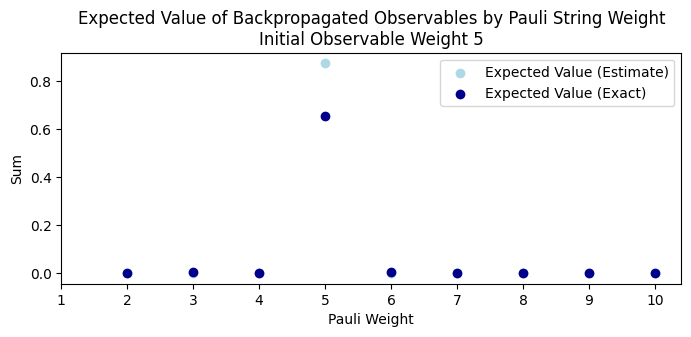

In [46]:
# estimated expected value by pauli weight
# exact expected value by pauli weight
# scatter plot
ev_est_dict = {}
ev_exact_dict = {}
obs_shad_df = pd.DataFrame(data_weight['obs_shad_dict'][0])
for p, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    if len([x for x in str(p) if x != 'I']) not in ev_est_dict:
        ev_est_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
        ev_exact_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])
    else:
        ev_est_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
        ev_exact_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])

# print(ev_est_dict)
plt.figure(figsize=(8, 3))

plt.scatter(ev_est_dict.keys(), ev_est_dict.values(), color='lightblue', label='Expected Value (Estimate)')
plt.scatter(ev_exact_dict.keys(), ev_exact_dict.values(), color='darkblue', label='Expected Value (Exact)')

plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

plt.xlabel('Pauli Weight')
plt.ylabel('Sum')
plt.title('Expected Value of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 5')
plt.legend()

{5: np.complex128(1.3676646802669399-1.6499166033741534e-18j), 6: np.complex128(-0.043692765503451726-5.08985435937726e-18j), 8: np.complex128(0.00025799160886913697-7.061384058191809e-21j), 3: np.complex128(0.000870079189753865+3.527361294252975e-18j), 4: np.complex128(0.13010102656863579-1.4421266620606477e-18j), 7: np.complex128(-0.014040079585263+2.806663941952231e-18j), 2: np.complex128(2.687289376194744e-05+1.0354988920817205e-19j), 9: np.complex128(3.882593025408344e-05+1.4917786291845668e-22j), 10: np.complex128(-2.308236766836145e-07+0j)}


/opt/anaconda3/envs/qiskit-obp/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/qiskit-obp/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_91424/492230210.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  est = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p_)]['estimate'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_91424/492230210.py:41: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exact = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p_)]['exact

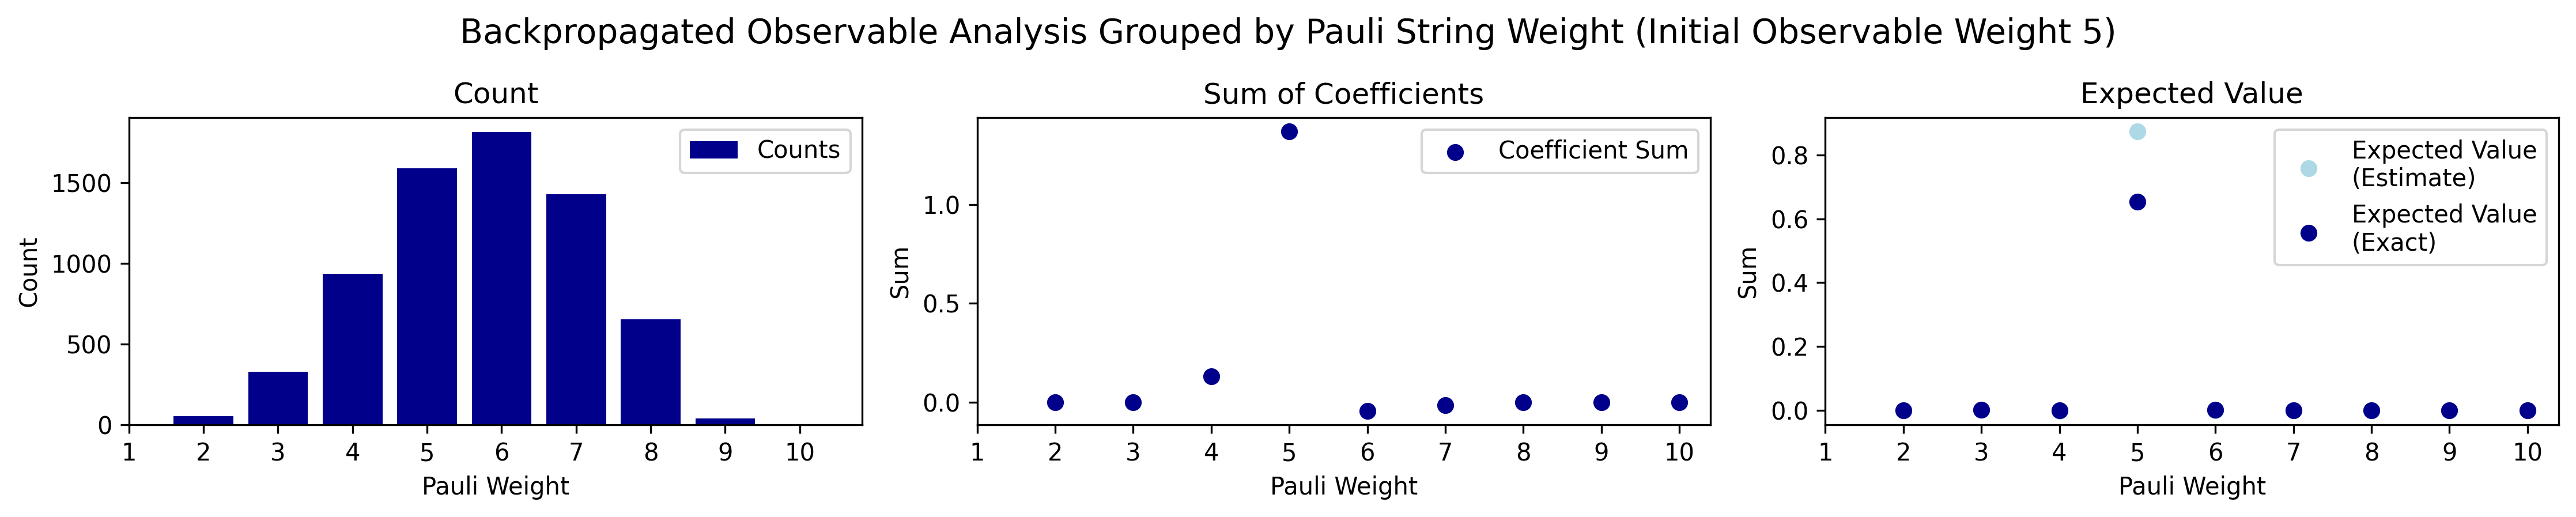

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3), dpi=300)
ax0, ax1, ax2 = axes

# --- Figure 1: Count of backpropagated observables by Pauli weight ---
p = {}
for d in data_weight['obs_shad_dict'][0]:
    w = len([x for x in d['obs'] if x != 'I'])
    p[w] = p.get(w, 0) + 1

ax0.bar(p.keys(), p.values(), color='darkblue', label='Counts')
ax0.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
ax0.set_xlabel('Pauli Weight')
ax0.set_ylabel('Count')
ax0.set_title('Count')
ax0.legend()

# --- Figure 2: Sum of coefficients by Pauli weight ---
coef_dict = {}
for p_, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    w = len([x for x in str(p_) if x != 'I'])
    if w not in coef_dict:
        coef_dict[w] = c
    else:
        coef_dict[w] += c

print(coef_dict)
ax1.scatter(coef_dict.keys(), coef_dict.values(), color='darkblue', label='Coefficient Sum')
ax1.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
ax1.set_xlabel('Pauli Weight')
ax1.set_ylabel('Sum')
ax1.set_title('Sum of Coefficients')
ax1.legend()

# --- Figure 3: Expected value (estimate vs exact) by Pauli weight ---
ev_est_dict = {}
ev_exact_dict = {}
obs_shad_df = pd.DataFrame(data_weight['obs_shad_dict'][0])
for p_, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    w = len([x for x in str(p_) if x != 'I'])
    est = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p_)]['estimate'])
    exact = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p_)]['exact'])
    if w not in ev_est_dict:
        ev_est_dict[w] = est
        ev_exact_dict[w] = exact
    else:
        ev_est_dict[w] += est
        ev_exact_dict[w] += exact

ax2.scatter(ev_est_dict.keys(), ev_est_dict.values(), color='lightblue', label='Expected Value\n(Estimate)')
ax2.scatter(ev_exact_dict.keys(), ev_exact_dict.values(), color='darkblue', label='Expected Value\n(Exact)')
ax2.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
ax2.set_xlabel('Pauli Weight')
ax2.set_ylabel('Sum')
ax2.set_title('Expected Value')
ax2.legend()


fig.suptitle('Backpropagated Observable Analysis Grouped by Pauli String Weight (Initial Observable Weight 5)', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 1.02])
# High-resolution export:
fig.savefig('pauli_weight_figures.png', dpi=300, bbox_inches='tight')

In [26]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data2'))
coef3_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs3.pkl')
obp3_df = pd.read_pickle(f'{data_path}/obp_bp10_obs3.pkl')

data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data3'))
coef9_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs9.pkl')
obp9_df = pd.read_pickle(f'{data_path}/obp_bp10_obs9.pkl')

data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data4'))
coef18_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs18.pkl')
obp18_df = pd.read_pickle(f'{data_path}/obp_bp10_obs18.pkl')

data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data5'))
coef36_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs36.pkl')
obp36_df = pd.read_pickle(f'{data_path}/obp_bp10_obs36.pkl')

data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_obs'))
coef21_df = pd.read_pickle(f'{data_path}/combine_obs21.pkl')
obp21_df = pd.read_pickle(f'{data_path}/obp_obs21.pkl')

data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_obs'))
coef24_df = pd.read_pickle(f'{data_path}/combine_obs24.pkl')
obp24_df = pd.read_pickle(f'{data_path}/obp_obs24.pkl')

In [27]:
# After creating all your line plots and before plt.show()

# Define the horizontal line value
y_target = 10e-3  # 10^-3

# Function to find intersection
def find_intersection(x_data, y_data, y_target):
    """Find x value where line crosses y_target using linear interpolation"""
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    
    # Find where the line crosses the target
    diff = y_data - y_target
    crossings = diff[:-1] * diff[1:] < 0
    
    if not crossings.any():
        return None
    
    # Get first crossing
    idx = np.where(crossings)[0][0]
    x0, y0 = x_data[idx], y_data[idx]
    x1, y1 = x_data[idx + 1], y_data[idx + 1]
    
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_target - y0) * (x1 - x0) / (y1 - y0)
        return x_intersect
    return None

def get_gb_df(obp_df, coef_df):
    obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
    obp_df['num_total_shots'] = obp_df['number of groups'] * obp_df['obp_shots']
    obs_num = obp_df['obs'].nunique()
    obp_df['obs_group'] = obp_df.index // obs_num
    coef_df['obs_group'] = coef_df.index // obs_num
    gb_df2 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
    gb_df1 = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()
    return gb_df1, gb_df2

gb_obp3, gb_coef3 = get_gb_df(obp3_df, coef3_df)
gb_obp9, gb_coef9 = get_gb_df(obp9_df, coef9_df)
gb_obp18, gb_coef18 = get_gb_df(obp18_df, coef18_df)
gb_obp21, gb_coef21 = get_gb_df(obp21_df, coef21_df)
gb_obp24, gb_coef24 = get_gb_df(obp24_df, coef24_df)
gb_obp36, gb_coef36 = get_gb_df(obp36_df, coef36_df)

# Find intersections for each line
print(f"\nIntersections with y = {y_target}:")
print("-" * 60)

datasets = [
    (gb_coef3['num_meas'], gb_coef3['abs_total_error'], '3 Obs Combined'),
    (gb_obp3['num_total_shots'], gb_obp3['abs_bp_error_shots'], '3 Obs OBP'),
    (gb_coef9['num_meas'], gb_coef9['abs_total_error'], '9 Obs Combined'),
    (gb_obp9['num_total_shots'], gb_obp9['abs_bp_error_shots'], '9 Obs OBP'),
    (gb_coef18['num_meas'], gb_coef18['abs_total_error'], '18 Obs Combined'),
    (gb_obp18['num_total_shots'], gb_obp18['abs_bp_error_shots'], '18 Obs OBP'),
    (gb_coef21['num_meas'], gb_coef21['abs_total_error'], '21 Obs Combined'),
    (gb_obp21['num_total_shots'], gb_obp21['abs_bp_error_shots'], '21 Obs OBP'),
    (gb_coef24['num_meas'], gb_coef24['abs_total_error'], '24 Obs Combined'),
    (gb_obp24['num_total_shots'], gb_obp24['abs_bp_error_shots'], '24 Obs OBP'),
    (gb_coef36['num_meas'], gb_coef36['abs_total_error'], '36 Obs Combined'),
    (gb_obp36['num_total_shots'], gb_obp36['abs_bp_error_shots'], '36 Obs OBP'),
]

intersections = []
qwc_groups = []
for i in [obp3_df, obp9_df, obp18_df, obp21_df, obp24_df, obp36_df]:
    qwc_groups.append(i['number of groups'].mean())
for x_data, y_data, label in datasets:
    x_intersect = find_intersection(x_data, y_data, y_target)
    intersections.append(x_intersect)
    if x_intersect:
        print(f"{label:45s}: x ≈ {x_intersect:,.2f}")
    else:
        print(f"{label:45s}: No intersection found")

# Group into pairs for improvement list
improvement = [intersections[i+1] / intersections[i] for i in range(0, len(intersections), 2)]
id = {}
for k, v in zip(qwc_groups, improvement):
    id[k] = v
print(id)


Intersections with y = 0.01:
------------------------------------------------------------
3 Obs Combined                               : x ≈ 11,152.92
3 Obs OBP                                    : x ≈ 571,503.20
9 Obs Combined                               : x ≈ 88,478.09
9 Obs OBP                                    : x ≈ 690,163.01
18 Obs Combined                              : x ≈ 41,240.75
18 Obs OBP                                   : x ≈ 1,274,231.79
21 Obs Combined                              : x ≈ 361,013.49
21 Obs OBP                                   : x ≈ 10,450,639.32
24 Obs Combined                              : x ≈ 399,377.83
24 Obs OBP                                   : x ≈ 1,881,321.77
36 Obs Combined                              : x ≈ 84,124.09
36 Obs OBP                                   : x ≈ 2,091,222.95
{np.float64(86.33333333333333): np.float64(51.242475817144886), np.float64(82.0): np.float64(7.8003832924588545), np.float64(154.0): np.float64(30.8973973888715

Slope: -0.049727427797627524


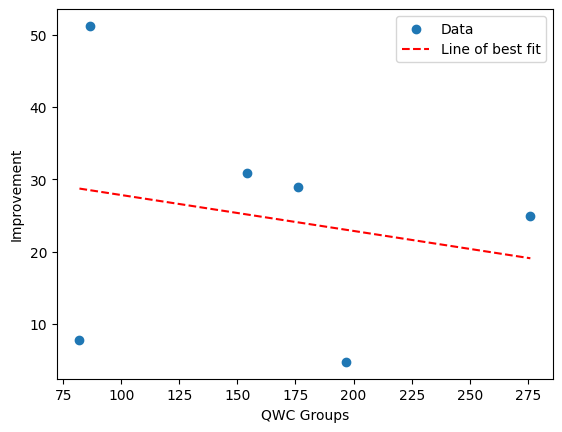

In [154]:
# given the number of QWC groups, choose direct measurement or shadow

# this needs to be for the same level of error to get that improvement I think though
# 3 observables - .15x improvement - 86 QWC groups
# 9 observables - 8.37x improvement - 82 QWC groups
# 18 observables - 11.28x improvement - 154 QWC groups
# 36 observables - 28.79x - 276 QWC groups

# improvement = [6, 8.37, 11.28, 28.79, 26.81]
# qwc_groups = [86, 82, 154, 276, 196.875]

coeffs = np.polyfit(qwc_groups, improvement, 1)
line = np.poly1d(coeffs)

print(f"Slope: {coeffs[0]}")

x_line = np.linspace(min(qwc_groups), max(qwc_groups), 100)

plt.scatter(qwc_groups, improvement, label='Data')
plt.plot(x_line, line(x_line), 'r--', label='Line of best fit')
plt.xlabel('QWC Groups')
plt.ylabel('Improvement')
plt.legend()
plt.show()

In [106]:
# y = mx + b
# 6 = .12296 * 86 + b
# y = .12296 * x - 4.57456

# x = 60
# y = .12296 * x - 4.57456

y = 1
x = (y + 4.57456) / .12296
print(x)

45.33636955107352


196.875
Intersection at num_total_shots ≈ 17021778.26
OBP-Shadow improvement is 26.81 times the minimum number of measurements for the coefficient truncation method.


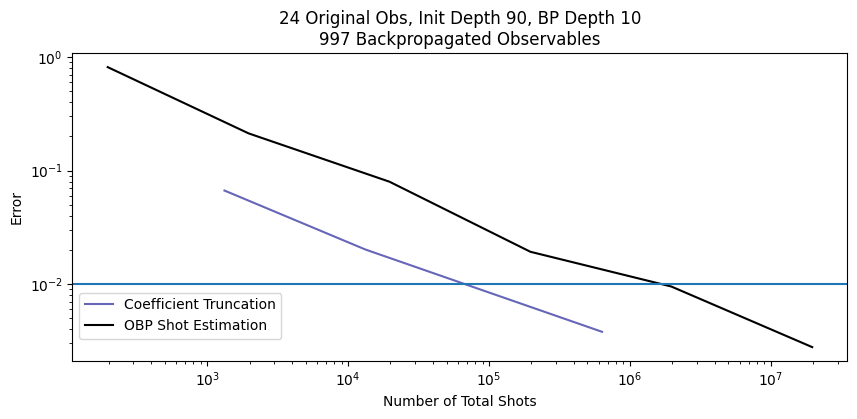

In [160]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_obs'))

coef_df = pd.read_pickle(f'{data_path}/combine_obs24.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp_obs24.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_total_shots'] = obp_df['number of groups'] * obp_df['obp_shots']

obs_num = obp_df['obs'].nunique()
coef_df['obs_group'] = coef_df.index // obs_num
obp_df['obs_group'] = obp_df.index // obs_num

gb1 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))

sns.lineplot(x=gb1['num_meas'], y=gb1['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='darkblue')
sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP Shot Estimation', color='black')

plt.axhline(y = 10e-3)

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

print(obp_df['number of groups'].mean())

y_hline = gb1['abs_total_error'].min()
y_min = gb1[gb1['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

In [185]:
shadow = np.log(997) * (3**8) / (10e-2**2)

In [186]:
obp = 196.875 * 10**6

In [187]:
if shadow > obp:
    print(f"obp: {shadow/obp}")
else:
    print(f"shadow: {obp/shadow}")

shadow: 43.45827924898188


In [166]:
np.log(51) * 3**5 / (0.01**2)

np.float64(9554336.28752011)

In [4]:
%pip install --upgrade pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 3.4 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.1
    Uninstalling pandas-2.3.1:
      Successfully uninstalled pandas-2.3.1
Note: you may need to restart the kernel to use updated packages.


ValueError: expected tuple of length 4, but got tuple of length 7

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

5.112797474502186


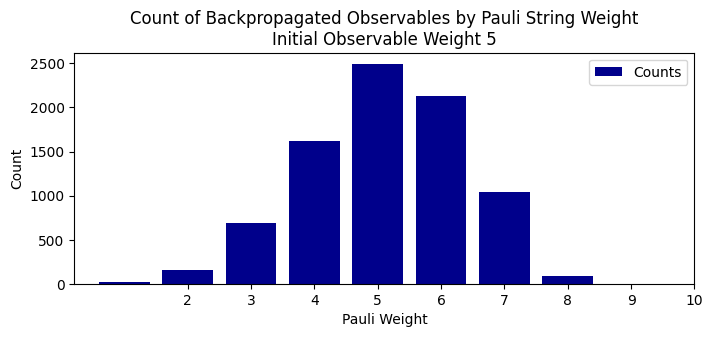

In [5]:
dat = os.path.abspath(os.path.join(os.getcwd(), '..', 'data5'))
dat_df = pd.read_pickle(f'{dat}/coef-trunc_init90_bp10_obs36.pkl')

p = {}
for d in dat_df['obs_shad_dict'][0]:

    if len([x for x in d['obs'] if x != 'I']) not in p:
        p[len([x for x in d['obs'] if x != 'I'])] = 1
    else:
        p[len([x for x in d['obs'] if x != 'I'])] += 1

avg = 0
count = 0
for k, v in p.items():
    avg += float(k) * float(v)
    count += float(v)
avg /= count
print(avg)

plt.figure(figsize=(8, 3))

plt.bar(p.keys(), p.values(), color='darkblue', label='Counts')

plt.xticks([2, 3, 4, 5, 6, 7, 8, 9, 10])

plt.xlabel('Pauli Weight')
plt.ylabel('Count')
plt.title('Count of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 5')
plt.legend()